In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy import text
import os

# Configuring visual defaults
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 150
plt.rcParams['font.size'] = 10

# Move to project root 
if os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")
print("Working directory:", os.getcwd())

load_dotenv() 

## Database Connection
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")
DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")

engine =create_engine(f"postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}")

with engine.connect() as conn:
    result = conn.execute(text("select count(*) from fraud_dw.fact_transactions"))
    count = result.scalar()
    print(f"Connected to database. Fact_transactions has {count:,} rows.")


Working directory: d:\Innomatics\Git_Uploads\Credit-card-risk-analytics
Connected to database. Fact_transactions has 590,540 rows.


In [33]:
## Query 1 --  Fraud rate by amount quintile

query1 = """

with amt_buckets as(
	select 		
			transaction_id,
			is_fraud,
			transaction_amt,
			ntile(5) over (order by transaction_amt) as amt_quintile
	from fraud_dw.fact_transactions
)

select 
		amt_quintile,
		count(*) 						as txn_count,
		round(min(transaction_amt),2) 	as min_amt,
		round(max(transaction_amt),2)	as max_amt,
		count(*) filter(where is_fraud)	as fraud_count,
		round(100.0 * count(*)
			filter (where is_fraud)/count(*),2)		as fraud_rate_pct
from amt_buckets
group by amt_quintile
order by amt_quintile;
"""

df1 = pd.read_sql(query1,engine)
df1

,amt_quintile,txn_count,min_amt,max_amt,fraud_count,fraud_rate_pct
0,1,118108,0.25,35.95,5296,4.48
1,2,118108,35.95,57.95,3232,2.74
2,3,118108,57.95,100.00,3678,3.11
3,4,118108,100.00,159.95,3223,2.73
4,5,118108,159.95,31937.39,5234,4.43


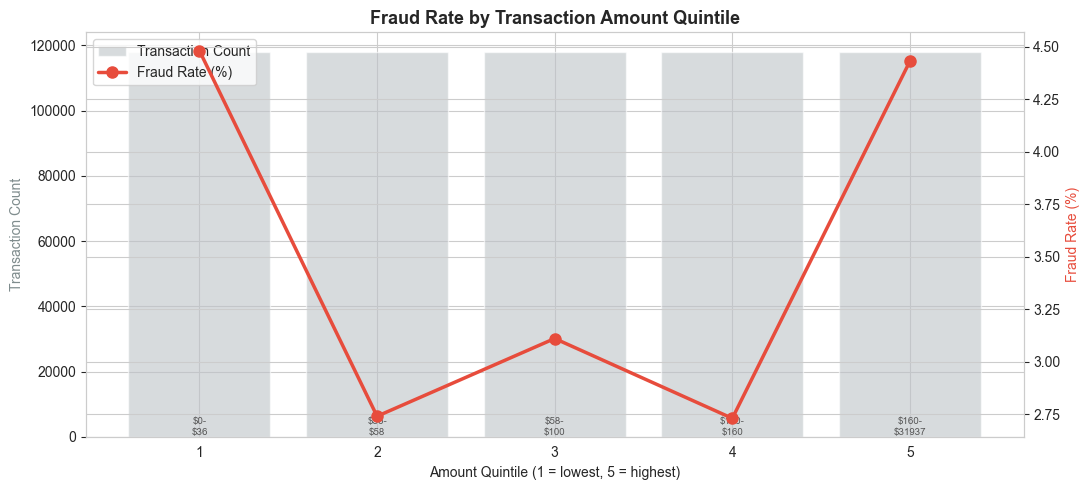

In [34]:
## Q1 plot

fig, ax1 = plt.subplots(figsize=(11, 5))
ax2 = ax1.twinx()

x = df1['amt_quintile']
ax1.bar(x, df1['txn_count'], color='#bdc3c7', alpha=0.6, label='Transaction Count')
ax1.set_xlabel('Amount Quintile (1 = lowest, 5 = highest)')
ax1.set_ylabel('Transaction Count', color='#7f8c8d')

ax2.plot(x, df1['fraud_rate_pct'], color='#e74c3c', 
         marker='o', linewidth=2.5, markersize=8, label='Fraud Rate (%)')
ax2.set_ylabel('Fraud Rate (%)', color='#e74c3c')

# Label each quintile with its dollar range
for xi, mn, mx in zip(x, df1['min_amt'], df1['max_amt']):
    ax1.text(xi, 0, f'${mn:.0f}-\n${mx:.0f}', ha='center', va='bottom', 
             fontsize=7, color='#555')

ax1.set_title('Fraud Rate by Transaction Amount Quintile',
              fontsize=13, fontweight='bold')

l1, lab1 = ax1.get_legend_handles_labels()
l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, loc='upper left')

plt.tight_layout()
plt.savefig('visuals/phase4_q1_amount_quintile.png', bbox_inches='tight')
plt.show()

In [6]:
## Query 2 -- Fraud rate by puschased email domain

query2 = """
select 	
		e.email_domain,
		e.domain_category,
		count(*) 									as txn_count,
		count(*) filter (where f.is_fraud) 			as fraud_count,
		round(100 * count(*)
			filter(where is_fraud)/count(*),2)		as fraud_rate_pct,
		round(100 * count(*) filter (where is_fraud)
				/ count(*) / 3.5,1)					as risk_multiple
from fraud_dw.fact_transactions f
join fraud_dw.dim_email_domain e
on f.purchase_email_id = e.email_domain_id
group by e.email_domain_id
order by fraud_rate_pct desc;"""

df2 = pd.read_sql(query2,engine)
df2.head()

,email_domain,domain_category,txn_count,fraud_count,fraud_rate_pct,risk_multiple
0,protonmail.com,anonymous,76,31,40.0,11.4
1,mail.com,anonymous,559,106,18.0,5.1
2,outlook.es,corporate_or_other,438,57,13.0,3.7
3,aim.com,corporate_or_other,315,40,12.0,3.4
4,outlook.com,free_webmail,5096,482,9.0,2.6


In [9]:
df2["risk_multiple"].value_counts()

risk_multiple
0.0     25
0.6     14
0.9      6
0.3      6
1.4      2
11.4     1
5.1      1
3.7      1
3.4      1
2.6      1
1.7      1
1.1      1
Name: count, dtype: int64

In [7]:
## Query 3 -- Fraud rate by device type

query3 = """
select 
		d.device_type,
		count(*) 							as txn_count,
		count(*) filter (where f.is_fraud) 			as fraud_count,
		round(100 * count(*)
			filter(where is_fraud)/count(*),2)		as fraud_rate_pct,
		round(100 * count(*) filter (where is_fraud)
				/ count(*) / 3.5,1)					as risk_multiple
from fraud_dw.fact_transactions f
join fraud_dw.dim_device d using (device_id)
group by d.device_type
order by fraud_rate_pct desc;"""

df3 = pd.read_sql(query3,engine)
df3

,device_type,txn_count,fraud_count,fraud_rate_pct,risk_multiple
0,mobile,55645,5657,10.0,2.9
1,desktop,85165,5554,6.0,1.7
2,unknown,449730,9452,2.0,0.6


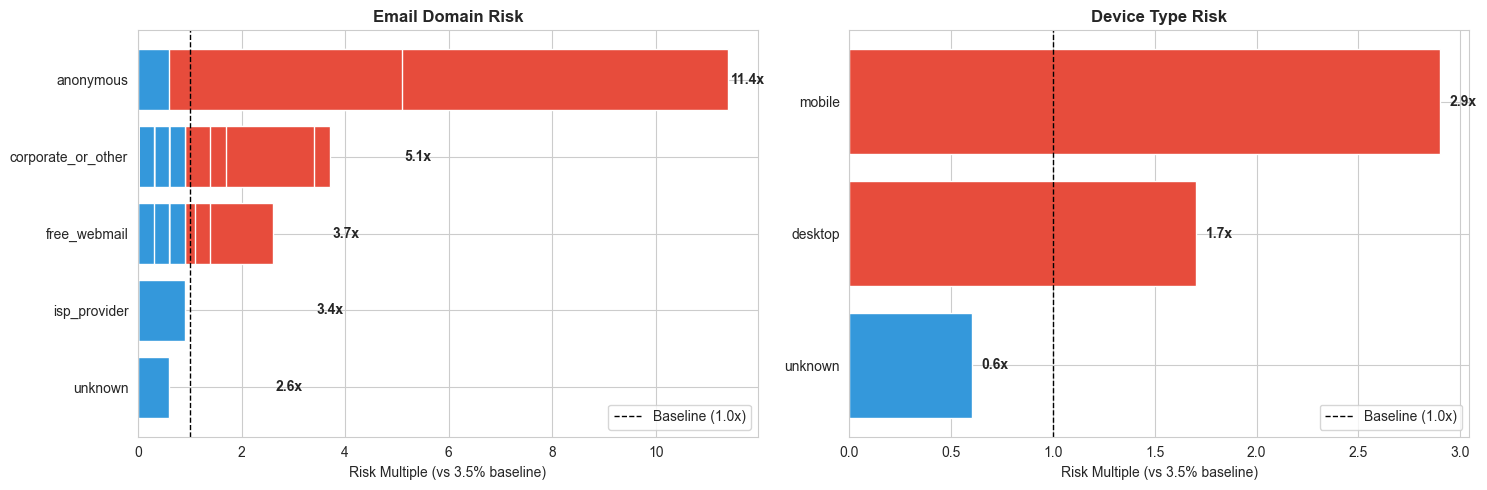

In [17]:
## Plot - Q2 and Q3 combined

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Email domain risk
colors_e = ['#e74c3c' if x >= 1 else '#3498db' for x in df2['risk_multiple']]
axes[0].barh(df2['domain_category'], df2['risk_multiple'], color=colors_e)
axes[0].axvline(1.0, color='black', linestyle='--', linewidth=1, label='Baseline (1.0x)')
axes[0].set_xlabel('Risk Multiple (vs 3.5% baseline)')
axes[0].set_title('Email Domain Risk', fontsize=12, fontweight='bold')
axes[0].invert_yaxis()
axes[0].legend()
capped_df =   df2[df2['risk_multiple'] >= 2.6]
for i, v in enumerate(capped_df["risk_multiple"]):
    axes[0].text(v + 0.05, i, f'{v:.1f}x', va='center', fontweight='bold')

# Device type risk
colors_d = ['#e74c3c' if x >= 1 else '#3498db' for x in df3['risk_multiple']]
axes[1].barh(df3['device_type'], df3['risk_multiple'], color=colors_d)
axes[1].axvline(1.0, color='black', linestyle='--', linewidth=1, label='Baseline (1.0x)')
axes[1].set_xlabel('Risk Multiple (vs 3.5% baseline)')
axes[1].set_title('Device Type Risk', fontsize=12, fontweight='bold')
axes[1].invert_yaxis()
axes[1].legend()
for i, v in enumerate(df3['risk_multiple']):
    axes[1].text(v + 0.05, i, f'{v:.1f}x', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('visuals/phase4_q2q3_risk_multiples.png', bbox_inches='tight')
plt.show()

In [19]:
## Q5 -- Risk profiles ranked by fraud connections

query5 = """with quaintiled as (
	select 
		f.is_fraud,
	    f.transaction_amt,
        p.product_category,
        c.card_type,
        d.device_type,
        e.domain_category,
		ntile(4) over (order by f.transaction_amt) as amt_quaintile

from fraud_dw.fact_transactions f 
join fraud_dw.dim_product p using (product_id)
join fraud_dw.dim_card c using (card_id)
join fraud_dw.dim_device d using (device_id)
join fraud_dw.dim_email_domain e 
        ON f.purchase_email_id = e.email_domain_id
)
select 
		product_category,
		card_type,
		domain_category,
		case
			when amt_quaintile=4 then 'High value' 
			 else 'Normal value' end as value_tier,
		 COUNT(*)                                            AS txn_count,
   		 COUNT(*) FILTER (WHERE is_fraud)                    AS fraud_count,
    	ROUND(100.0 * COUNT(*) FILTER (WHERE is_fraud) 
                / COUNT(*), 2)                          AS fraud_rate_pct,
    	ROUND(100.0 * COUNT(*) FILTER (WHERE is_fraud) 
                / COUNT(*) / 3.5, 1)                    AS risk_multiple
from quaintiled 
group by product_category, card_type, domain_category, value_tier
having count(*) >= 300
order by fraud_rate_pct desc
limit 20;"""

df5 = pd.read_sql(query5,engine)
df5.head()

,product_category,card_type,domain_category,value_tier,txn_count,fraud_count,fraud_rate_pct,risk_multiple
0,Card-Not-Present,Credit,free_webmail,High value,1215,320,26.34,7.5
1,Hotel/Travel,Debit,free_webmail,High value,1279,316,24.71,7.1
2,Hotel/Travel,Credit,free_webmail,High value,1803,433,24.02,6.9
3,Card-Not-Present,Credit,unknown,Normal value,920,189,20.54,5.9
4,Card-Not-Present,Credit,free_webmail,Normal value,20364,3763,18.48,5.3


In [20]:
## Plot -- Q5

# The leaderboard is best as a color-graded table
df5_display = df5.copy()

styled = df5_display.style.background_gradient(
    subset=['fraud_rate_pct', 'risk_multiple'], cmap='Reds'
).format({
    'fraud_rate_pct': '{:.2f}%',
    'risk_multiple': '{:.1f}x',
    'txn_count': '{:,}',
    'fraud_count': '{:,}'
}).set_caption("Top 20 Risk Profiles — Candidate Rules for Phase 5")

styled

,product_category,card_type,domain_category,value_tier,txn_count,fraud_count,fraud_rate_pct,risk_multiple
0,Card-Not-Present,Credit,free_webmail,High value,"1,215",320,26.34%,7.5x
1,Hotel/Travel,Debit,free_webmail,High value,"1,279",316,24.71%,7.1x
2,Hotel/Travel,Credit,free_webmail,High value,"1,803",433,24.02%,6.9x
3,Card-Not-Present,Credit,unknown,Normal value,920,189,20.54%,5.9x
4,Card-Not-Present,Credit,free_webmail,Normal value,"20,364","3,763",18.48%,5.3x
5,Card-Not-Present,Debit,free_webmail,High value,"1,260",154,12.22%,3.5x
6,Hotel/Travel,Credit,anonymous,High value,431,47,10.90%,3.1x
7,Card-Not-Present,Credit,anonymous,Normal value,"2,793",302,10.81%,3.1x
8,Card-Not-Present,Debit,unknown,Normal value,"1,163",110,9.46%,2.7x
9,Card-Not-Present,Debit,free_webmail,Normal value,"33,017","2,931",8.88%,2.5x


In [21]:
## Q6 --  Does high risk segments have more total fraud

query6 = """

WITH enriched AS (
    SELECT 
        f.is_fraud,
        p.product_category,
        e.domain_category
    FROM fraud_dw.fact_transactions f
    JOIN fraud_dw.dim_product p USING (product_id)
    JOIN fraud_dw.dim_email_domain e 
        ON f.purchase_email_id = e.email_domain_id
),
totals AS (
    SELECT COUNT(*) FILTER (WHERE is_fraud) AS total_fraud FROM enriched
)
SELECT 
    e.product_category,
    e.domain_category,
    COUNT(*)                                            AS txn_count,
    COUNT(*) FILTER (WHERE e.is_fraud)                  AS fraud_count,
    ROUND(100.0 * COUNT(*) FILTER (WHERE e.is_fraud) 
                / COUNT(*), 2)                          AS fraud_rate_pct,
    ROUND(100.0 * COUNT(*) FILTER (WHERE e.is_fraud) 
                / t.total_fraud, 2)                     AS pct_of_all_fraud
FROM enriched e
CROSS JOIN totals t
GROUP BY e.product_category, e.domain_category, t.total_fraud
HAVING COUNT(*) FILTER (WHERE e.is_fraud) >= 50
ORDER BY fraud_count DESC
LIMIT 15;
"""

df6 = pd.read_sql(query6,engine)
df6

,product_category,domain_category,txn_count,fraud_count,fraud_rate_pct,pct_of_all_fraud
0,Card-Not-Present,free_webmail,56020,7183,12.82,34.76
1,Web Purchase,free_webmail,319039,6430,2.02,31.12
2,Web Purchase,unknown,80629,1791,2.22,8.67
3,Hotel/Travel,free_webmail,26617,1341,5.04,6.49
4,Retail,free_webmail,24666,1245,5.05,6.03
5,Subscription,unknown,11628,686,5.90,3.32
6,Card-Not-Present,anonymous,5834,377,6.46,1.82
7,Card-Not-Present,unknown,2153,311,14.44,1.51
8,Web Purchase,anonymous,18954,297,1.57,1.44
9,Web Purchase,isp_provider,13909,278,2.00,1.35


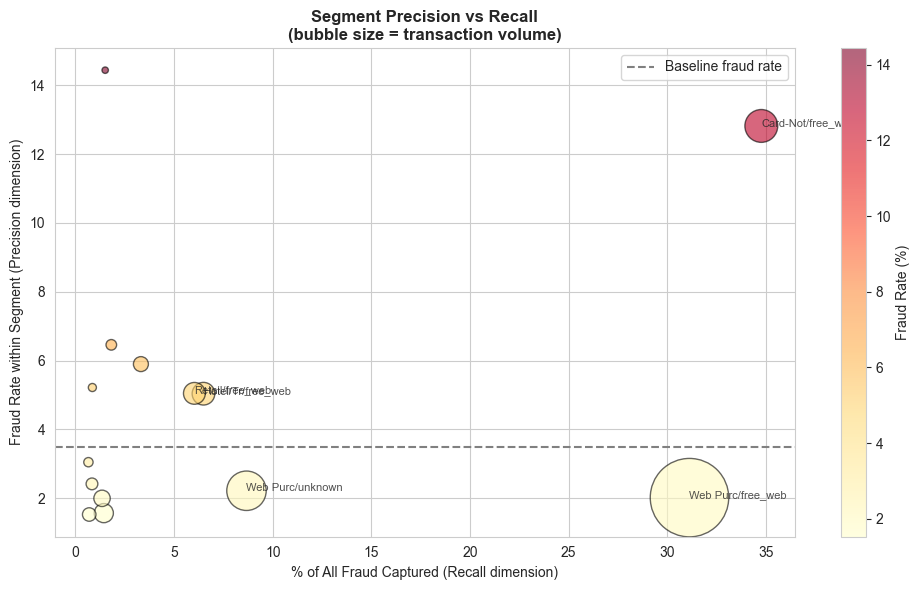

In [23]:
## Plot -- Q6

fig, ax = plt.subplots(figsize=(10, 6))

scatter = ax.scatter(df6['pct_of_all_fraud'], df6['fraud_rate_pct'],
                     s=df6['txn_count']/100, alpha=0.6, 
                     c=df6['fraud_rate_pct'], cmap='YlOrRd', edgecolors='black')

ax.set_xlabel('% of All Fraud Captured (Recall dimension)')
ax.set_ylabel('Fraud Rate within Segment (Precision dimension)')
ax.set_title('Segment Precision vs Recall\n(bubble size = transaction volume)',
             fontsize=12, fontweight='bold')
ax.axhline(3.5, color='gray', linestyle='--', label='Baseline fraud rate')

# Annotate notable segments
for _, row in df6.head(5).iterrows():
    ax.annotate(f"{row['product_category'][:8]}/{row['domain_category'][:8]}",
                (row['pct_of_all_fraud'], row['fraud_rate_pct']),
                fontsize=8, alpha=0.8)

plt.colorbar(scatter, label='Fraud Rate (%)')
ax.legend()
plt.tight_layout()
plt.savefig('visuals/phase4_q6_precision_recall.png', bbox_inches='tight')
plt.show()

## Phase 4 Summary

**Key findings:**

1. **Amount matters:** The highest amount quintile shows a 4% fraud rate vs 2% 
   in the lowest — fraudsters concentrate in the 0.25 to 35.95 and 159.95 to 313937 value range. That is at lowest value and highest value range.

2. **Email domain is a strong signal:** `anonymous` domains carry a 11.4x risk multiple; 
   `free_webmail` 2.6x. ISP-tied emails are the safest at 0.9x.

3. **Device signal:** Mobile transactions show the highest device-level risk at 2.9x baseline.

4. **The strongest combination:** Card-Not-present + Credit + free_webmail + High value 
   produces a 26.34% fraud rate — a 7.5x risk multiple. This is the top candidate rule.

5. **Precision-recall tradeoff:** The highest-precision segments are small; the 
   highest-recall segments are broader but dilute precision.
